<a href="https://colab.research.google.com/github/mushrafi88/MSE_510/blob/main/Copy_of_Final_Active_Experimental_Design.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Active Experimental Design under Noise and Budget Constraints

In many experiments we aim to discover how a property depends on composition or processing conditions. This is often a case for characterization by XRD, SPM, Raman etc. of spread combinatorial libraries, where a continuous range of compositions is explored on a single substrate.

A mainstream approach for automating such experiments is Bayesian optimization (BO), where a surrogate model (e.g. Gaussian process) is used to predict the property and guide the selection of the next measurement in an active, closed-loop manner.

However, classical BO typically assumes idealized conditions and does not explicitly account for key experimental constraints, such as:

- measurement noise that depends on acquisition time,
- limited experimental budget,
- and cost of moving between measurement locations.

In this challenge, the goal is to design a strategy that, using a surrogate model, decides:

- **where to measure**,
- **in what order**,
- and **for how long**,

in order to efficiently explore and recover the underlying functional dependence under these realistic conditions.

###gif_Classical BO with GP surrogate model



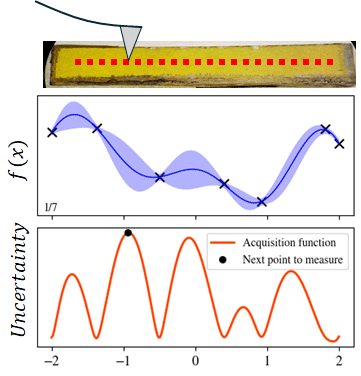

## Functions

In [40]:
!pip install gpytorch

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import gpytorch

In [42]:
#@title target function

# F1 — Smooth unimodal
def unimodal(x):
    x = np.asarray(x)
    res = 0.15 * (x + 2)**2 + 0.03 * (x - 1)**4
    return res/20


# F2 — Double-well
def double_well(x):
    x = np.asarray(x)
    res = 0.08 * (x**2 - 4)**2 + 0.15 * x

    return res/10


# F3 — Multimodal (Rastrigin-like, 1D)
def multimodal(x):
    x = np.asarray(x)
    res = 10 + x**2 - 7 * np.cos(2 * np.pi * x) + 9 * np.sin(1.4 * np.pi * x)
    return res/40


# F4 — Broad + narrow minima
def broad_narrow(x):
    x = np.asarray(x)

    res = (
        1
        - 1.0 * np.exp(-((x + 1.5)**2) / (2 * 0.9**2))
        - 1.6 * np.exp(-((x - 1.0)**2) / (2 * 0.18**2))
    )
    return res

In [43]:
#@title simple noise models

def noise_constant(x = None, t = None, sigma0=0.1):
    t = np.asarray(t)
    return sigma0 * np.ones_like(t, dtype=float)

def noise_decay_floor(x = None, t = None, sigma_min=0.05, A=0.18, tau=1.0):
    t = np.asarray(t)
    return sigma_min + A * np.exp(-t / tau)

In [44]:
#@title heteroskedastic_noise_model

def make_heteroskedastic_noise_model(f, xlim, n_grid=200, smooth_window=3):
    """
    Build heteroskedastic noise model on a fixed domain.

    Parameters
    ----------
    f : callable
        Ground truth function
    xlim : tuple (xmin, xmax)
        Domain of interest
    """

    xmin, xmax = xlim
    x_grid = np.linspace(xmin, xmax, n_grid)
    y_grid = f(x_grid)

    # gradient
    grad = np.abs(np.gradient(y_grid, x_grid, edge_order=2))

    # smoothing
    if smooth_window > 1:
        kernel = np.ones(smooth_window) / smooth_window
        half = smooth_window // 2
        grad_s = np.pad(grad, pad_width=half, mode="reflect")
        grad = np.convolve(grad_s, kernel, mode="valid")

    # normalization
    scale = np.percentile(grad, 95) + 1e-12
    grad_norm_grid = grad / scale

    def noise_model(x, t, sigma_min=0.05, sigma_max=0.5, tau=1.5):
        x = np.asarray(x, dtype=float)
        t = np.asarray(t, dtype=float)

        g = np.interp(x, x_grid, grad_norm_grid)
        sigma0_x = sigma_min + (sigma_max - sigma_min) * g

        return sigma_min + (sigma0_x - sigma_min) * np.exp(-t / tau)

    return noise_model

In [45]:
#@title measurement simulator

class MeasurementSimulator:
    def __init__(self, ground_truth_model, noise_model, rng=None, **noise_kwargs):
        """
        Parameters
        ----------
        ground_truth_model : callable
            Function f(x)
        noise_model : callable
            Function sigma(x, t, **noise_kwargs)
        rng : None, int, or np.random.Generator
            Random generator or seed
        **noise_kwargs
            Default parameters for noise_model
        """
        self.f = ground_truth_model
        self.noise_model = noise_model
        self.noise_kwargs = noise_kwargs

        if rng is None:
            self.rng = np.random.default_rng()
        elif isinstance(rng, (int, np.integer)):
            self.rng = np.random.default_rng(rng)
        else:
            self.rng = rng

    def measure(self, coords, **noise_kwargs):
        """
        coords : array of shape (N, 2)
            Columns are (x, t)

        Returns
        -------
        y_meas : array of shape (N,)
            Noisy measurements
        """
        coords = np.asarray(coords, dtype=float)

        if coords.ndim != 2 or coords.shape[1] != 2:
            raise ValueError("coords must have shape (N, 2)")

        x = coords[:, 0]
        t = coords[:, 1]

        kwargs = {**self.noise_kwargs, **noise_kwargs}
        sigma = np.asarray(self.noise_model(x, t, **kwargs), dtype=float)
        noise = self.rng.normal(0.0, sigma, size=len(x))

        return self.f(x) + noise

    __call__ = measure

In [46]:
#@title gp functions

import torch
import gpytorch


def gp_predict(x_train, y_train, x_test, training_iter=100, lr=0.1):
    """
    Fit GP on (x_train, y_train) and predict on x_test.

    Parameters
    ----------
    x_train : array-like (N,)
    y_train : array-like (N,)
    x_test  : array-like (M,)

    Returns
    -------
    mean : (M,)
    std  : (M,)
    """

    # convert to torch
    x_train = torch.as_tensor(x_train, dtype=torch.float32)
    y_train = torch.as_tensor(y_train, dtype=torch.float32)
    x_test  = torch.as_tensor(x_test, dtype=torch.float32)

    # ensure 2D inputs
    if x_train.ndim == 1:
        x_train = x_train.unsqueeze(-1)
    if x_test.ndim == 1:
        x_test = x_test.unsqueeze(-1)

    # define model
    likelihood = gpytorch.likelihoods.GaussianLikelihood()

    class GPModel(gpytorch.models.ExactGP):
        def __init__(self, train_x, train_y, likelihood):
            super().__init__(train_x, train_y, likelihood)
            self.mean_module = gpytorch.means.ConstantMean()
            self.covar_module = gpytorch.kernels.ScaleKernel(
                gpytorch.kernels.RBFKernel()
            )

        def forward(self, x):
            mean = self.mean_module(x)
            covar = self.covar_module(x)
            return gpytorch.distributions.MultivariateNormal(mean, covar)

    model = GPModel(x_train, y_train, likelihood)

    # train
    model.train()
    likelihood.train()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    for _ in range(training_iter):
        optimizer.zero_grad()
        output = model(x_train)
        loss = -mll(output, y_train)
        loss.backward()
        optimizer.step()

    # predict
    model.eval()
    likelihood.eval()

    with torch.no_grad():
        pred = likelihood(model(x_test))
        mean = pred.mean.cpu().numpy()
        std = pred.stddev.cpu().numpy()

    return mean, std

In [47]:
#@title cost models

def travel_cost(dx, speed=0.5) -> float:
  return abs(dx) / speed


## Introduction

In [48]:
x = np.linspace(-4,4,100) #spatial coordinate (compositional/parameter space)
t = np.linspace(0,10,100) #acquisition time

We suggest selecting one of the following four “ground truth” functions to represent the underlying functionality.

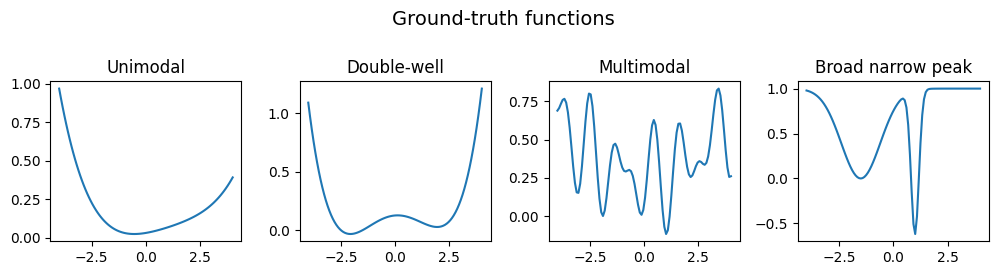

In [49]:
#ground truth functions
fig, ax = plt.subplots(1,4, figsize=(10, 2.7))

ax[0].plot(x, unimodal(x))
ax[1].plot(x, double_well(x))
ax[2].plot(x, multimodal(x))
ax[3].plot(x, broad_narrow(x))

ax[0].set_title('Unimodal')
ax[1].set_title('Double-well')
ax[2].set_title('Multimodal')
ax[3].set_title('Broad narrow peak')

fig.suptitle('Ground-truth functions', y=1, fontsize=14)

plt.tight_layout()

To emulate noisy measurements, we consider two homoscedastic noise models. The first is a **constant noise** model (trivial case), where the measurement precision is independent of acquisition time. The second is a **decaying noise** model, where the noise decreases exponentially with acquisition time and approaches a maximum achievable precision.

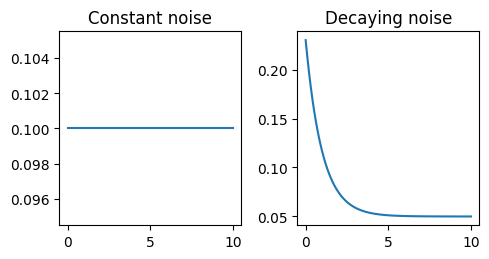

In [50]:
#homoskedastic noise model

fig, ax = plt.subplots(1,2, figsize=(5, 2.7))

ax[0].plot(t, noise_constant(x, t))
ax[0].set_title('Constant noise')
ax[1].plot(t, noise_decay_floor(x, t))
ax[1].set_title('Decaying noise')

plt.tight_layout()

For those seeking more hardcore challenge, we also suggest a **heteroscedastic noise model**, where the measurement noise depends on the location. In our specific case, the noise level is proportional to the local gradient of the underlying function, while still decaying with acquisition time toward a limiting precision.

Text(0.5, 0.98, 'Heteroskedastic noise model')

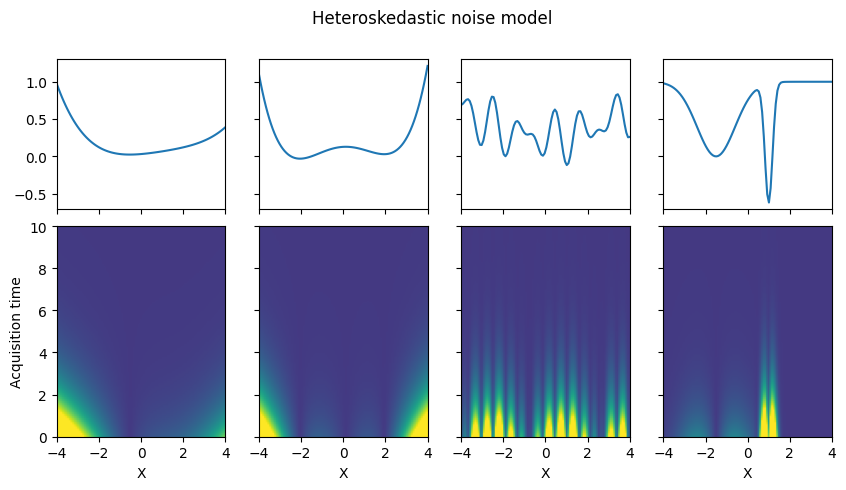

In [51]:
#@title heteroskedastic noise model

funcs = [unimodal, double_well, multimodal, broad_narrow]

fig, ax = plt.subplots(2, 4, figsize=(10, 5),
                       height_ratios=(1,1.5),
                       sharex=True,
                       sharey='row',
                       gridspec_kw={'hspace': 0.05})

for i,ax0_ in enumerate(ax[0]):
  ax0_.plot(x, funcs[i](x))

for i,ax1_ in enumerate(ax[1]):
  noise_model = make_heteroskedastic_noise_model(funcs[i], (-4, 4))
  ax1_.imshow(noise_model(x, t.reshape(-1,1)),
              origin='lower',
              extent=[x.min(), x.max(), t.min(), t.max()],
              vmax=.3, vmin=0)
  ax1_.set_xlabel('X')

ax[1,0].set_ylabel('Acquisition time')

fig.suptitle('Heteroskedastic noise model')


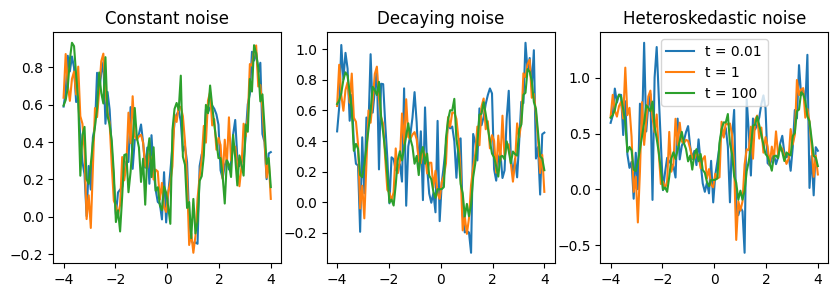

In [52]:
#@title example: grid measurements with different acqusition time

x = np.linspace(-4,4, 100) #x grid

durations = [0.01, 1, 100] #select durations
model = multimodal #select model [unimodal, double_well, multimodal, broad_narrow]

noise_heter_model = make_heteroskedastic_noise_model(model, (-4, 4))

sim_const = MeasurementSimulator(
    ground_truth_model=model,
    noise_model=noise_constant,
    rng=123,
)

sim_decay = MeasurementSimulator(
    ground_truth_model=model,
    noise_model=noise_decay_floor,
    rng=123,
)

sim_heterosk = MeasurementSimulator(
    ground_truth_model=model,
    noise_model=noise_heter_model,
    rng=123,
)

fig, ax = plt.subplots(1, 3, figsize=(10,3))

for d in durations:
  d_ar = np.ones(len(x))*d
  coords = np.vstack([x, d_ar]).T

  ax[0].plot(coords[:,0], sim_const.measure(coords), label = f't = {d}')
  ax[1].plot(coords[:,0], sim_decay.measure(coords), label = f't = {d}')
  ax[2].plot(coords[:,0], sim_heterosk.measure(coords), label = f't = {d}')

ax[0].set_title('Constant noise')
ax[1].set_title('Decaying noise')
ax[2].set_title('Heteroskedastic noise')
ax[2].legend()

In [53]:
#@title example: surrogate modeling

#homoskedatic noise model: [noise_constant, noise_decay_floor]
#ground truth models: [unimodal, double_well, multimodal, broad_narrow]


#If we select the heteroskedastic noise model, we first need to construct it. For the homoskedastic cases, the models are already defined.
noise_heter_model = make_heteroskedastic_noise_model(double_well, xlim=(-4, 4)) #please define the x range

meas_sim = MeasurementSimulator(
    ground_truth_model=double_well,
    noise_model=noise_heter_model,
    rng=123,
)

In [54]:

#define x_grid on the explored interval

x_grid = np.linspace(-4, 4, 500)

# For this example, select 4 random locations in the range (-4, 4)
x = np.random.random(7) * 8 - 4

# Set acquisition time (t = 3) for all locations
t = np.ones(len(x)) * 1

# Form the coordinate array: [[x1, t1], [x2, t2], ...]
coords = np.column_stack([x, t])

#make "measurements"
y = meas_sim.measure(coords)

#surrogate modeling
mean, std = gp_predict(x, y, x_grid, training_iter=100, lr=0.1)

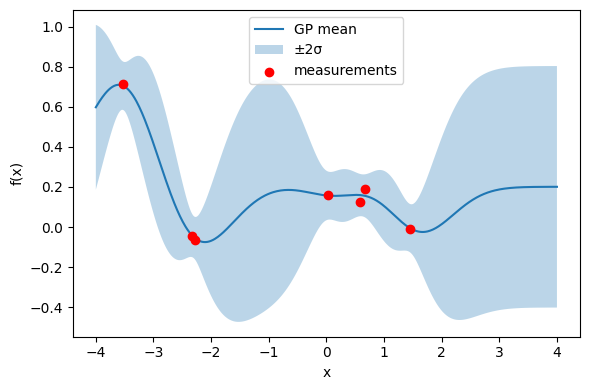

In [55]:
plt.figure(figsize=(6, 4))

# GP mean
plt.plot(x_grid, mean, label="GP mean")

# uncertainty band
plt.fill_between(
  x_grid,
  mean - 2 * std,
  mean + 2 * std,
  alpha=0.3,
  label="±2σ"
)

# training points
plt.scatter(x, y, color="red", zorder=3, label="measurements")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.tight_layout()
plt.show()

For simplicity, we treat time as the cost function. The cost of a single measurement is therefore equal to its acquisition time. In addition, we introduce a travel cost, which accounts for moving between measurement locations and is assumed to be proportional to the distance between them.

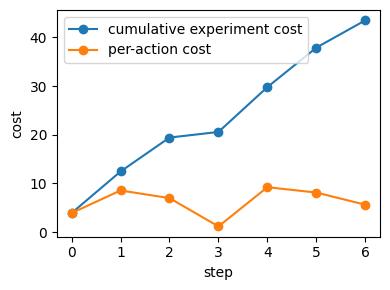

In [56]:
#@title total experiment cost

# initial position
x0 = 0

# displacement between consecutive points (including first move from x0)
dx = x - np.append(x0, x[:-1])

# cost of each action = travel cost + acquisition time
action_costs = travel_cost(dx) + t

# visualize costs
fig = plt.figure(figsize=(4,3))
plt.plot(np.cumsum(action_costs), 'o-', label='cumulative experiment cost')
plt.plot(action_costs, 'o-', label='per-action cost')

plt.xlabel('step')
plt.ylabel('cost')
plt.legend()
plt.tight_layout()




---


## Final
---



### Part I

Part I. First, let's make sure that there is indeed a problem. Assume that total experimental time is 80, an dmoving form one location to another takes 5 time units (and does not depend on the measurement distance). Here, if we do measurement with just one location, we have low noise, but we definitely have not learned ur function f(x). At the same time, if we do measurement at 16 locations, all out time is spent moving. So the optimum is somewhere between.

You are free to choose the ground truth function and noise model (decaying or heteroskedastic, use constant noise only for benchmarking if needed).

In [57]:
B = 80 #your budget (can be different)

meas_sim = MeasurementSimulator(
    ground_truth_model=double_well, #choose gt function
    noise_model=noise_decay_floor,  #choose noise model
    rng=123,
)

I.1. First, experiment with the simple gird search. Let's assume that we run measurements at N = 1, 2, 3, .. , 16 points. How does MSE error and predictive uncertaity change with N? WHat is optimal time?

In [58]:
# Shared setup for Part I
import pandas as pd

move_cost_per_point = 5
fixed_move_cost = move_cost_per_point
rng_seed = 123

ground_truth = double_well
noise_model = noise_decay_floor

x_min, x_max = -4, 4
x_grid = np.linspace(x_min, x_max, 500)
y_true = ground_truth(x_grid)

N_values = np.arange(1, 17)
duration_values = [0.5, 1, 2, 3, 5, 7, 10]

def minmax_normalize(values):
    values = np.asarray(values)
    v_min = np.min(values)
    v_max = np.max(values)

    if v_max == v_min:
        return np.zeros_like(values)

    return (values - v_min) / (v_max - v_min)


In [59]:
# Part I.1 - Simple grid search over N = 1, 2, ..., 16

results = []

for N in N_values:
    movement_cost = move_cost_per_point * N
    acquisition_budget = B - movement_cost

    if acquisition_budget < 0:
        continue

    t_each = acquisition_budget / N
    x_train = np.linspace(x_min, x_max, N)
    t_train = np.ones(N) * t_each
    coords = np.column_stack([x_train, t_train])

    meas_sim = MeasurementSimulator(
        ground_truth_model=ground_truth,
        noise_model=noise_model,
        rng=rng_seed,
    )

    y_train = meas_sim.measure(coords)

    mean, std = gp_predict(
        x_train,
        y_train,
        x_grid,
        training_iter=100,
        lr=0.1,
    )

    mse = np.mean((mean - y_true)**2)
    mean_uncertainty = np.mean(std)
    total_cost = movement_cost + np.sum(t_train)

    results.append({
        "N": N,
        "movement_cost": movement_cost,
        "acquisition_budget": acquisition_budget,
        "t_each": t_each,
        "total_cost": total_cost,
        "MSE": mse,
        "mean_uncertainty": mean_uncertainty,
    })

results_df = pd.DataFrame(results)
results_df


,N,movement_cost,acquisition_budget,t_each,total_cost,MSE,mean_uncertainty
0,1,5,75,75.000000,80.0,0.772747,0.013797
1,2,10,70,35.000000,80.0,0.919004,0.075989
2,3,15,65,21.666667,80.0,0.400758,0.490651
3,4,20,60,15.000000,80.0,0.175170,0.523206
4,5,25,55,11.000000,80.0,0.105763,0.524042
5,6,30,50,8.333333,80.0,0.091734,0.496395
6,7,35,45,6.428571,80.0,0.076253,0.453012
7,8,40,40,5.000000,80.0,0.055445,0.440083
8,9,45,35,3.888889,80.0,0.005096,0.209772
9,10,50,30,3.000000,80.0,0.003464,0.159953


In [60]:
# Best N based on lowest MSE
best_row = results_df.loc[results_df["MSE"].idxmin()]

print("Best N based on MSE:")
print(best_row)

Best N based on MSE:
N                     11.000000
movement_cost         55.000000
acquisition_budget    25.000000
t_each                 2.272727
total_cost            80.000000
MSE                    0.001604
mean_uncertainty       0.113645
Name: 10, dtype: float64


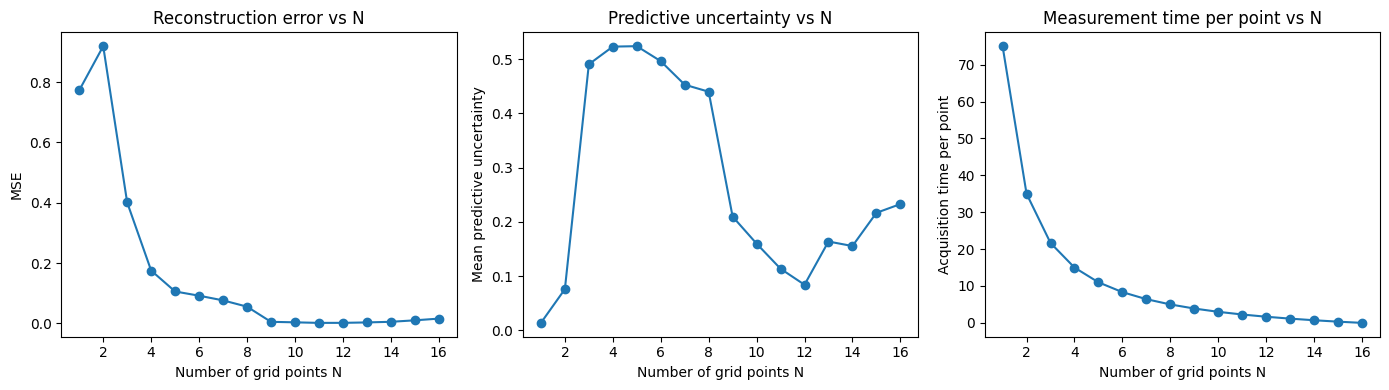

In [61]:
# -----------------------------
# Plot MSE and uncertainty vs N
# -----------------------------

fig, ax = plt.subplots(1, 3, figsize=(14, 4))

ax[0].plot(results_df["N"], results_df["MSE"], "o-")
ax[0].set_xlabel("Number of grid points N")
ax[0].set_ylabel("MSE")
ax[0].set_title("Reconstruction error vs N")

ax[1].plot(results_df["N"], results_df["mean_uncertainty"], "o-")
ax[1].set_xlabel("Number of grid points N")
ax[1].set_ylabel("Mean predictive uncertainty")
ax[1].set_title("Predictive uncertainty vs N")

ax[2].plot(results_df["N"], results_df["t_each"], "o-")
ax[2].set_xlabel("Number of grid points N")
ax[2].set_ylabel("Acquisition time per point")
ax[2].set_title("Measurement time per point vs N")

plt.tight_layout()
plt.show()

In [62]:
# -----------------------------
# Weighted score for choosing best N
# -----------------------------

results_df["MSE_norm"] = minmax_normalize(results_df["MSE"])
results_df["uncertainty_norm"] = minmax_normalize(results_df["mean_uncertainty"])
results_df["t_each_norm"] = minmax_normalize(results_df["t_each"])

# Weights
w_mse = 0.60
w_uncertainty = 0.30
w_time = 0.10

# MSE and uncertainty are minimized. Longer acquisition time is preferred,
# so the time contribution uses (1 - t_each_norm).
results_df["weighted_score"] = (
    w_mse * results_df["MSE_norm"]
    + w_uncertainty * results_df["uncertainty_norm"]
    + w_time * (1 - results_df["t_each_norm"])
)

best_weighted_row = results_df.loc[results_df["weighted_score"].idxmin()]

print("Best N based on weighted score:")
print(best_weighted_row)


Best N based on weighted score:
N                     12.000000
movement_cost         60.000000
acquisition_budget    20.000000
t_each                 1.666667
total_cost            80.000000
MSE                    0.001709
mean_uncertainty       0.084130
MSE_norm               0.000114
uncertainty_norm       0.137843
t_each_norm            0.022222
weighted_score         0.139199
Name: 11, dtype: float64


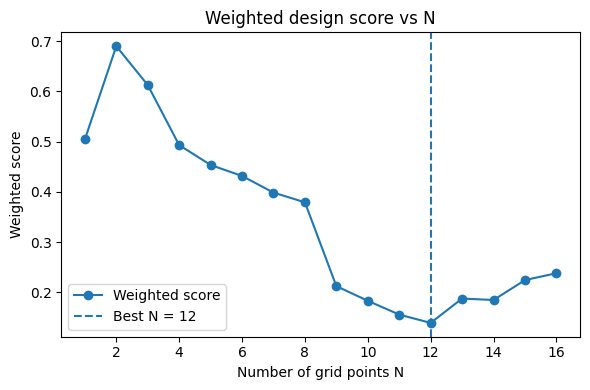

In [63]:
plt.figure(figsize=(6, 4))

plt.plot(
    results_df["N"],
    results_df["weighted_score"],
    "o-",
    label="Weighted score"
)

plt.axvline(
    best_weighted_row["N"],
    linestyle="--",
    label=f"Best N = {int(best_weighted_row['N'])}"
)

plt.xlabel("Number of grid points N")
plt.ylabel("Weighted score")
plt.title("Weighted design score vs N")
plt.legend()
plt.tight_layout()
plt.show()

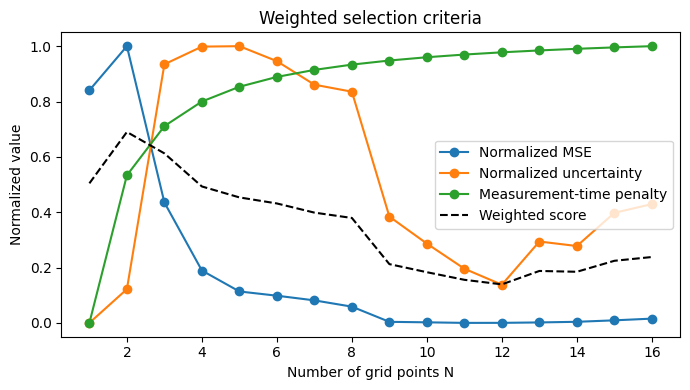

In [64]:
plt.figure(figsize=(7, 4))

plt.plot(results_df["N"], results_df["MSE_norm"], "o-", label="Normalized MSE")
plt.plot(results_df["N"], results_df["uncertainty_norm"], "o-", label="Normalized uncertainty")
plt.plot(results_df["N"], 1 - results_df["t_each_norm"], "o-", label="Measurement-time penalty")
plt.plot(results_df["N"], results_df["weighted_score"], "k--", label="Weighted score")

plt.xlabel("Number of grid points N")
plt.ylabel("Normalized value")
plt.title("Weighted selection criteria")
plt.legend()
plt.tight_layout()
plt.show()

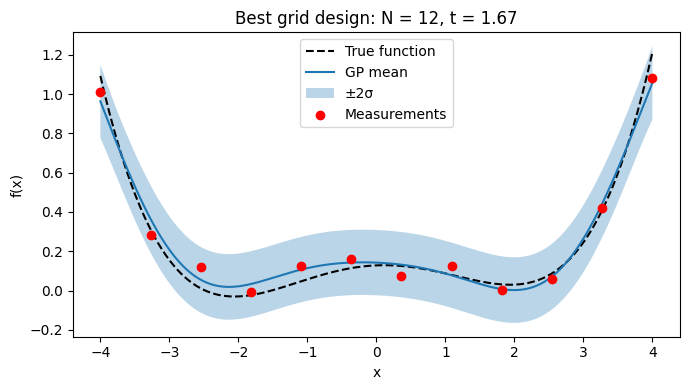

In [65]:
# -----------------------------
# Re-run best case and plot GP fit
# -----------------------------

best_N = int(best_weighted_row["N"])
best_t_each = best_weighted_row["t_each"]

x_train = np.linspace(x_min, x_max, best_N)
t_train = np.ones(best_N) * best_t_each
coords = np.column_stack([x_train, t_train])

meas_sim = MeasurementSimulator(
    ground_truth_model=ground_truth,
    noise_model=noise_model,
    rng=123,
)

y_train = meas_sim.measure(coords)

mean, std = gp_predict(
    x_train,
    y_train,
    x_grid,
    training_iter=100,
    lr=0.1
)

plt.figure(figsize=(7, 4))

plt.plot(x_grid, y_true, "k--", label="True function")
plt.plot(x_grid, mean, label="GP mean")

plt.fill_between(
    x_grid,
    mean - 2 * std,
    mean + 2 * std,
    alpha=0.3,
    label="±2σ"
)

plt.scatter(x_train, y_train, color="red", zorder=3, label="Measurements")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title(f"Best grid design: N = {best_N}, t = {best_t_each:.2f}")
plt.legend()
plt.tight_layout()
plt.show()

I.2. Now let's assume that you run this as a Bayesian Optimization cycle for fixed duration. Make the same estimate

In [66]:
# Part I.2 - Bayesian Optimization cycle with fixed acquisition duration

bo_results = []
bo_histories = {}


def run_bo_fixed_duration(
    t_fixed,
    B=80,
    fixed_move_cost=5,
    ground_truth=double_well,
    noise_model=noise_decay_floor,
    x_min=-4,
    x_max=4,
    x_grid=None,
    rng=123,
    training_iter=100,
    lr=0.1,
    min_dist=0.15,
):
    """
    Bayesian optimization / active learning cycle for fixed acquisition time.

    Acquisition rule:
        choose x where GP predictive uncertainty is largest.

    Cost per point:
        fixed_move_cost + t_fixed
    """

    if x_grid is None:
        x_grid = np.linspace(x_min, x_max, 500)

    y_true = ground_truth(x_grid)

    meas_sim = MeasurementSimulator(
        ground_truth_model=ground_truth,
        noise_model=noise_model,
        rng=rng,
    )

    cost_per_measurement = fixed_move_cost + t_fixed
    n_init = min(3, int(B // cost_per_measurement))

    if n_init < 1:
        raise ValueError("Budget is too small for even one measurement.")

    x_train = np.linspace(x_min, x_max, n_init)
    t_train = np.ones(n_init) * t_fixed

    coords = np.column_stack([x_train, t_train])
    y_train = meas_sim.measure(coords)

    total_cost = n_init * cost_per_measurement
    history = []

    for i in range(n_init):
        history.append({
            "step": i + 1,
            "x": x_train[i],
            "t": t_fixed,
            "cost": cost_per_measurement,
            "total_cost": (i + 1) * cost_per_measurement,
            "type": "initial",
        })

    while total_cost + cost_per_measurement <= B:
        mean, std = gp_predict(
            x_train,
            y_train,
            x_grid,
            training_iter=training_iter,
            lr=lr,
        )

        acquisition = std.copy()
        for x_old in x_train:
            acquisition[np.abs(x_grid - x_old) < min_dist] = -np.inf

        next_index = np.argmax(acquisition)
        x_next = x_grid[next_index]

        coords_next = np.array([[x_next, t_fixed]])
        y_next = meas_sim.measure(coords_next)[0]

        x_train = np.append(x_train, x_next)
        y_train = np.append(y_train, y_next)
        t_train = np.append(t_train, t_fixed)
        total_cost += cost_per_measurement

        history.append({
            "step": len(x_train),
            "x": x_next,
            "t": t_fixed,
            "cost": cost_per_measurement,
            "total_cost": total_cost,
            "type": "BO",
        })

    mean, std = gp_predict(
        x_train,
        y_train,
        x_grid,
        training_iter=training_iter,
        lr=lr,
    )

    mse = np.mean((mean - y_true)**2)
    mean_uncertainty = np.mean(std)

    return {
        "t_fixed": t_fixed,
        "N_points": len(x_train),
        "total_cost": total_cost,
        "MSE": mse,
        "mean_uncertainty": mean_uncertainty,
        "x_train": x_train,
        "y_train": y_train,
        "t_train": t_train,
        "mean": mean,
        "std": std,
        "history": pd.DataFrame(history),
    }


In [67]:
# -----------------------------
# Run BO for each fixed duration
# -----------------------------

for t_fixed in duration_values:

    result = run_bo_fixed_duration(
        t_fixed=t_fixed,
        B=B,
        fixed_move_cost=fixed_move_cost,
        ground_truth=ground_truth,
        noise_model=noise_model,
        x_min=x_min,
        x_max=x_max,
        x_grid=x_grid,
        rng=123,
        training_iter=100,
        lr=0.1,
    )

    bo_histories[t_fixed] = result

    bo_results.append({
        "t_fixed": result["t_fixed"],
        "N_points": result["N_points"],
        "total_cost": result["total_cost"],
        "MSE": result["MSE"],
        "mean_uncertainty": result["mean_uncertainty"],
    })

bo_results_df = pd.DataFrame(bo_results)

bo_results_df

,t_fixed,N_points,total_cost,MSE,mean_uncertainty
0,0.5,14,77.0,0.005599,0.254019
1,1.0,13,78.0,0.005858,0.096506
2,2.0,11,77.0,0.001829,0.095878
3,3.0,10,80.0,0.002406,0.071049
4,5.0,8,80.0,0.010642,0.243450
5,7.0,6,72.0,0.032283,0.302359
6,10.0,5,75.0,0.161857,0.307221


In [68]:
# -----------------------------
# Weighted score for BO results
# -----------------------------

bo_results_df["MSE_norm"] = minmax_normalize(bo_results_df["MSE"])
bo_results_df["uncertainty_norm"] = minmax_normalize(bo_results_df["mean_uncertainty"])
bo_results_df["N_norm"] = minmax_normalize(bo_results_df["N_points"])

# Weights
w_mse = 0.50
w_uncertainty = 0.35
w_points = 0.15

bo_results_df["weighted_score"] = (
    w_mse * bo_results_df["MSE_norm"]
    + w_uncertainty * bo_results_df["uncertainty_norm"]
    + w_points * (1 - bo_results_df["N_norm"])
)

best_bo_row = bo_results_df.loc[bo_results_df["weighted_score"].idxmin()]

print("Best fixed duration based on weighted score:")
print(best_bo_row)

Best fixed duration based on weighted score:
t_fixed              1.000000
N_points            13.000000
total_cost          78.000000
MSE                  0.005858
mean_uncertainty     0.096506
MSE_norm             0.025175
uncertainty_norm     0.107790
N_norm               0.888889
weighted_score       0.066981
Name: 1, dtype: float64


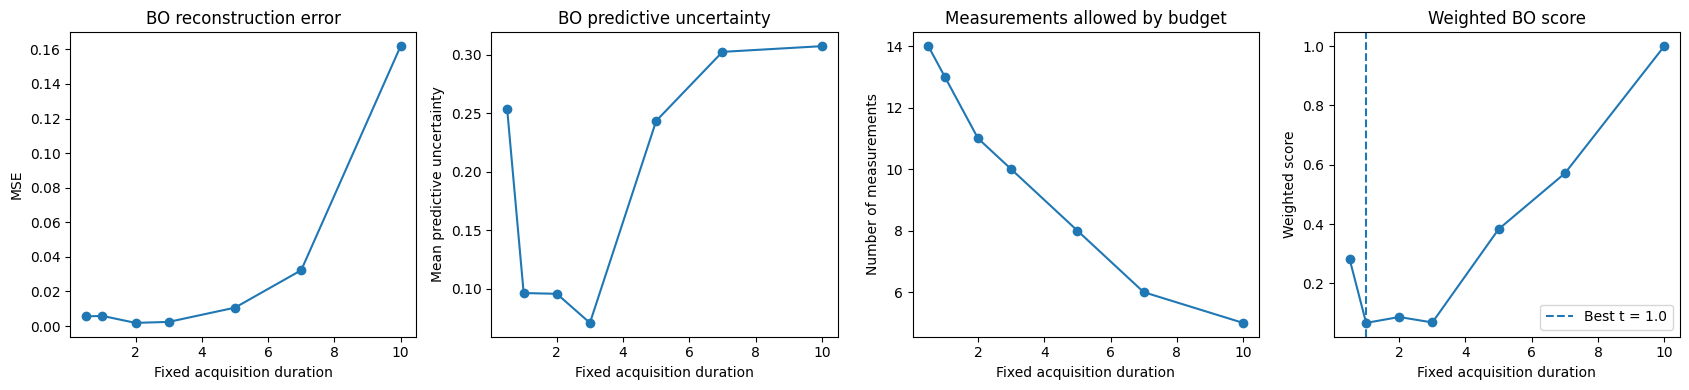

In [69]:
# -----------------------------
# Plot MSE, uncertainty, and number of points
# -----------------------------

fig, ax = plt.subplots(1, 4, figsize=(17, 4))

ax[0].plot(bo_results_df["t_fixed"], bo_results_df["MSE"], "o-")
ax[0].set_xlabel("Fixed acquisition duration")
ax[0].set_ylabel("MSE")
ax[0].set_title("BO reconstruction error")

ax[1].plot(bo_results_df["t_fixed"], bo_results_df["mean_uncertainty"], "o-")
ax[1].set_xlabel("Fixed acquisition duration")
ax[1].set_ylabel("Mean predictive uncertainty")
ax[1].set_title("BO predictive uncertainty")

ax[2].plot(bo_results_df["t_fixed"], bo_results_df["N_points"], "o-")
ax[2].set_xlabel("Fixed acquisition duration")
ax[2].set_ylabel("Number of measurements")
ax[2].set_title("Measurements allowed by budget")

ax[3].plot(bo_results_df["t_fixed"], bo_results_df["weighted_score"], "o-")
ax[3].axvline(
    best_bo_row["t_fixed"],
    linestyle="--",
    label=f"Best t = {best_bo_row['t_fixed']}"
)
ax[3].set_xlabel("Fixed acquisition duration")
ax[3].set_ylabel("Weighted score")
ax[3].set_title("Weighted BO score")
ax[3].legend()

plt.tight_layout()
plt.show()

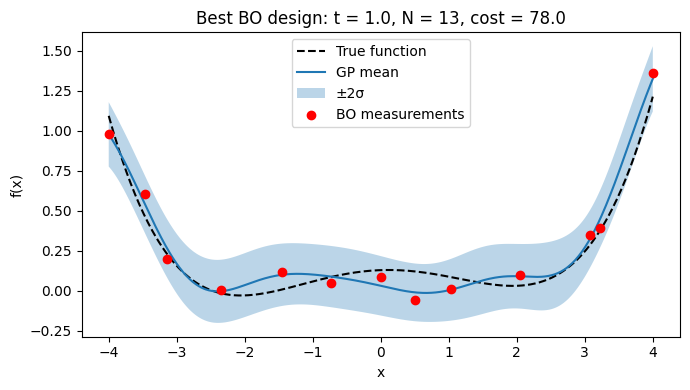

In [70]:
# -----------------------------
# Plot best BO reconstruction
# -----------------------------

best_t_fixed = best_bo_row["t_fixed"]
best_bo_result = bo_histories[best_t_fixed]

x_train = best_bo_result["x_train"]
y_train = best_bo_result["y_train"]
mean = best_bo_result["mean"]
std = best_bo_result["std"]

plt.figure(figsize=(7, 4))

plt.plot(x_grid, y_true, "k--", label="True function")
plt.plot(x_grid, mean, label="GP mean")

plt.fill_between(
    x_grid,
    mean - 2 * std,
    mean + 2 * std,
    alpha=0.3,
    label="±2σ"
)

plt.scatter(
    x_train,
    y_train,
    color="red",
    zorder=3,
    label="BO measurements"
)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title(
    f"Best BO design: t = {best_t_fixed}, "
    f"N = {len(x_train)}, cost = {best_bo_result['total_cost']:.1f}"
)
plt.legend()
plt.tight_layout()
plt.show()

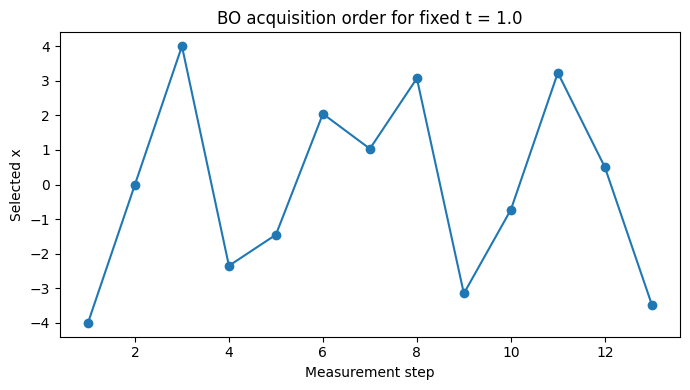

,step,x,t,cost,total_cost,type
0,1,-4.000000,1,6,6,initial
1,2,0.000000,1,6,12,initial
2,3,4.000000,1,6,18,initial
3,4,-2.348697,1,6,24,BO
4,5,-1.450902,1,6,30,BO
5,6,2.044088,1,6,36,BO
6,7,1.034068,1,6,42,BO
7,8,3.070140,1,6,48,BO
8,9,-3.150301,1,6,54,BO
9,10,-0.729459,1,6,60,BO


In [71]:
# -----------------------------
# Plot BO measurement order
# -----------------------------

history = best_bo_result["history"]

plt.figure(figsize=(7, 4))

plt.plot(history["step"], history["x"], "o-")

plt.xlabel("Measurement step")
plt.ylabel("Selected x")
plt.title(f"BO acquisition order for fixed t = {best_t_fixed}")
plt.tight_layout()
plt.show()

history

I.3. Now asusme that the cost of mocing is proportional to the travelled length. Explore how BO works in this case.

In [72]:
# Part I.3 - BO with distance-dependent movement cost

speed = 0.5
x0 = 0.0


def run_bo_distance_cost(
    t_fixed,
    B=80,
    speed=0.5,
    x0=0.0,
    ground_truth=double_well,
    noise_model=noise_decay_floor,
    x_min=-4,
    x_max=4,
    x_grid=None,
    rng=123,
    training_iter=100,
    lr=0.1,
    min_dist=0.15,
):
    """
    Bayesian optimization with distance-dependent movement cost.

    Movement cost:
        C_move = |x_next - x_current| / speed

    Measurement cost:
        C_measure = t_fixed

    Total action cost:
        C_action = C_move + t_fixed

    Acquisition rule:
        score(x) = GP_uncertainty(x) / action_cost(x)
    """

    if x_grid is None:
        x_grid = np.linspace(x_min, x_max, 500)

    y_true = ground_truth(x_grid)

    meas_sim = MeasurementSimulator(
        ground_truth_model=ground_truth,
        noise_model=noise_model,
        rng=rng,
    )

    current_x = x0
    total_cost = 0.0
    total_travel_cost = 0.0
    total_measurement_cost = 0.0
    total_path_length = 0.0

    x_train = []
    y_train = []
    t_train = []
    history = []

    first_x = current_x
    first_travel = travel_cost(first_x - current_x, speed=speed)
    first_action_cost = first_travel + t_fixed

    if first_action_cost > B:
        raise ValueError("Budget too small for first measurement.")

    coords = np.array([[first_x, t_fixed]])
    first_y = meas_sim.measure(coords)[0]

    x_train.append(first_x)
    y_train.append(first_y)
    t_train.append(t_fixed)

    total_cost += first_action_cost
    total_travel_cost += first_travel
    total_measurement_cost += t_fixed
    total_path_length += abs(first_x - current_x)
    current_x = first_x

    history.append({
        "step": 1,
        "x": first_x,
        "t": t_fixed,
        "travel_cost": first_travel,
        "measurement_cost": t_fixed,
        "action_cost": first_action_cost,
        "total_cost": total_cost,
        "current_x_after": current_x,
        "type": "initial",
    })

    x_train = np.asarray(x_train)
    y_train = np.asarray(y_train)
    t_train = np.asarray(t_train)
    step = 1

    while True:
        remaining_budget = B - total_cost

        if remaining_budget < t_fixed:
            break

        mean, std = gp_predict(
            x_train,
            y_train,
            x_grid,
            training_iter=training_iter,
            lr=lr,
        )

        candidate_travel_cost = travel_cost(x_grid - current_x, speed=speed)
        candidate_action_cost = candidate_travel_cost + t_fixed
        feasible = candidate_action_cost <= remaining_budget

        too_close = np.zeros_like(x_grid, dtype=bool)
        for x_old in x_train:
            too_close |= np.abs(x_grid - x_old) < min_dist

        feasible = feasible & (~too_close)

        if not np.any(feasible):
            break

        acquisition = np.full_like(x_grid, -np.inf, dtype=float)
        acquisition[feasible] = std[feasible] / candidate_action_cost[feasible]

        next_index = np.argmax(acquisition)
        x_next = x_grid[next_index]

        move_cost = travel_cost(x_next - current_x, speed=speed)
        action_cost = move_cost + t_fixed

        if total_cost + action_cost > B:
            break

        coords_next = np.array([[x_next, t_fixed]])
        y_next = meas_sim.measure(coords_next)[0]

        x_train = np.append(x_train, x_next)
        y_train = np.append(y_train, y_next)
        t_train = np.append(t_train, t_fixed)

        total_cost += action_cost
        total_travel_cost += move_cost
        total_measurement_cost += t_fixed
        total_path_length += abs(x_next - current_x)

        current_x = x_next
        step += 1

        history.append({
            "step": step,
            "x": x_next,
            "t": t_fixed,
            "travel_cost": move_cost,
            "measurement_cost": t_fixed,
            "action_cost": action_cost,
            "total_cost": total_cost,
            "current_x_after": current_x,
            "type": "BO",
        })

    mean, std = gp_predict(
        x_train,
        y_train,
        x_grid,
        training_iter=training_iter,
        lr=lr,
    )

    mse = np.mean((mean - y_true)**2)
    mean_uncertainty = np.mean(std)

    return {
        "t_fixed": t_fixed,
        "N_points": len(x_train),
        "total_cost": total_cost,
        "total_travel_cost": total_travel_cost,
        "total_measurement_cost": total_measurement_cost,
        "total_path_length": total_path_length,
        "MSE": mse,
        "mean_uncertainty": mean_uncertainty,
        "x_train": x_train,
        "y_train": y_train,
        "t_train": t_train,
        "mean": mean,
        "std": std,
        "history": pd.DataFrame(history),
    }


In [73]:
# -----------------------------
# Run distance-aware BO
# -----------------------------

i3_results = []
i3_histories = {}

for t_fixed in duration_values:

    result = run_bo_distance_cost(
        t_fixed=t_fixed,
        B=B,
        speed=speed,
        x0=x0,
        ground_truth=ground_truth,
        noise_model=noise_model,
        x_min=x_min,
        x_max=x_max,
        x_grid=x_grid,
        rng=123,
        training_iter=100,
        lr=0.1,
        min_dist=0.15,
    )

    i3_histories[t_fixed] = result

    i3_results.append({
        "t_fixed": result["t_fixed"],
        "N_points": result["N_points"],
        "total_cost": result["total_cost"],
        "total_travel_cost": result["total_travel_cost"],
        "total_measurement_cost": result["total_measurement_cost"],
        "total_path_length": result["total_path_length"],
        "MSE": result["MSE"],
        "mean_uncertainty": result["mean_uncertainty"],
    })

i3_results_df = pd.DataFrame(i3_results)

i3_results_df

,t_fixed,N_points,total_cost,total_travel_cost,total_measurement_cost,total_path_length,MSE,mean_uncertainty
0,0.5,50,56.310621,31.310621,25.0,15.655311,0.003140,0.176506
1,1.0,48,79.118236,31.118236,48.0,15.559118,0.002152,0.122417
2,2.0,28,79.967936,23.967936,56.0,11.983968,0.003993,0.103361
3,3.0,23,77.961924,8.961924,69.0,4.480962,0.030073,0.338072
4,5.0,14,75.947896,5.947896,70.0,2.973948,0.082196,0.076147
5,7.0,10,72.869739,2.869739,70.0,1.434870,0.082713,0.052145
6,10.0,7,71.907816,1.907816,70.0,0.953908,0.083484,0.047619


In [74]:
# -----------------------------
# Weighted score for I.3
# -----------------------------

i3_results_df["MSE_norm"] = minmax_normalize(i3_results_df["MSE"])
i3_results_df["uncertainty_norm"] = minmax_normalize(i3_results_df["mean_uncertainty"])
i3_results_df["N_norm"] = minmax_normalize(i3_results_df["N_points"])
i3_results_df["path_norm"] = minmax_normalize(i3_results_df["total_path_length"])

# Weights
w_mse = 0.40
w_uncertainty = 0.30
w_points = 0.20
w_path = 0.10

i3_results_df["weighted_score"] = (
    w_mse * i3_results_df["MSE_norm"]
    + w_uncertainty * i3_results_df["uncertainty_norm"]
    + w_points * (1 - i3_results_df["N_norm"])
    + w_path * i3_results_df["path_norm"]
)

best_i3_row = i3_results_df.loc[i3_results_df["weighted_score"].idxmin()]

print("Best I.3 design based on weighted score:")
print(best_i3_row)

i3_results_df

Best I.3 design based on weighted score:
t_fixed                    1.000000
N_points                  48.000000
total_cost                79.118236
total_travel_cost         31.118236
total_measurement_cost    48.000000
total_path_length         15.559118
MSE                        0.002152
mean_uncertainty           0.122417
MSE_norm                   0.000000
uncertainty_norm           0.257523
N_norm                     0.953488
path_norm                  0.993457
weighted_score             0.185905
Name: 1, dtype: float64


,t_fixed,N_points,total_cost,total_travel_cost,total_measurement_cost,total_path_length,MSE,mean_uncertainty,MSE_norm,uncertainty_norm,N_norm,path_norm,weighted_score
0,0.5,50,56.310621,31.310621,25.0,15.655311,0.003140,0.176506,0.012146,0.443743,1.000000,1.000000,0.237981
1,1.0,48,79.118236,31.118236,48.0,15.559118,0.002152,0.122417,0.000000,0.257523,0.953488,0.993457,0.185905
2,2.0,28,79.967936,23.967936,56.0,11.983968,0.003993,0.103361,0.022632,0.191915,0.488372,0.750273,0.243980
3,3.0,23,77.961924,8.961924,69.0,4.480962,0.030073,0.338072,0.343293,1.000000,0.372093,0.239913,0.586890
4,5.0,14,75.947896,5.947896,70.0,2.973948,0.082196,0.076147,0.984157,0.098220,0.162791,0.137405,0.604311
5,7.0,10,72.869739,2.869739,70.0,1.434870,0.082713,0.052145,0.990515,0.015581,0.069767,0.032715,0.590198
6,10.0,7,71.907816,1.907816,70.0,0.953908,0.083484,0.047619,1.000000,0.000000,0.000000,0.000000,0.600000


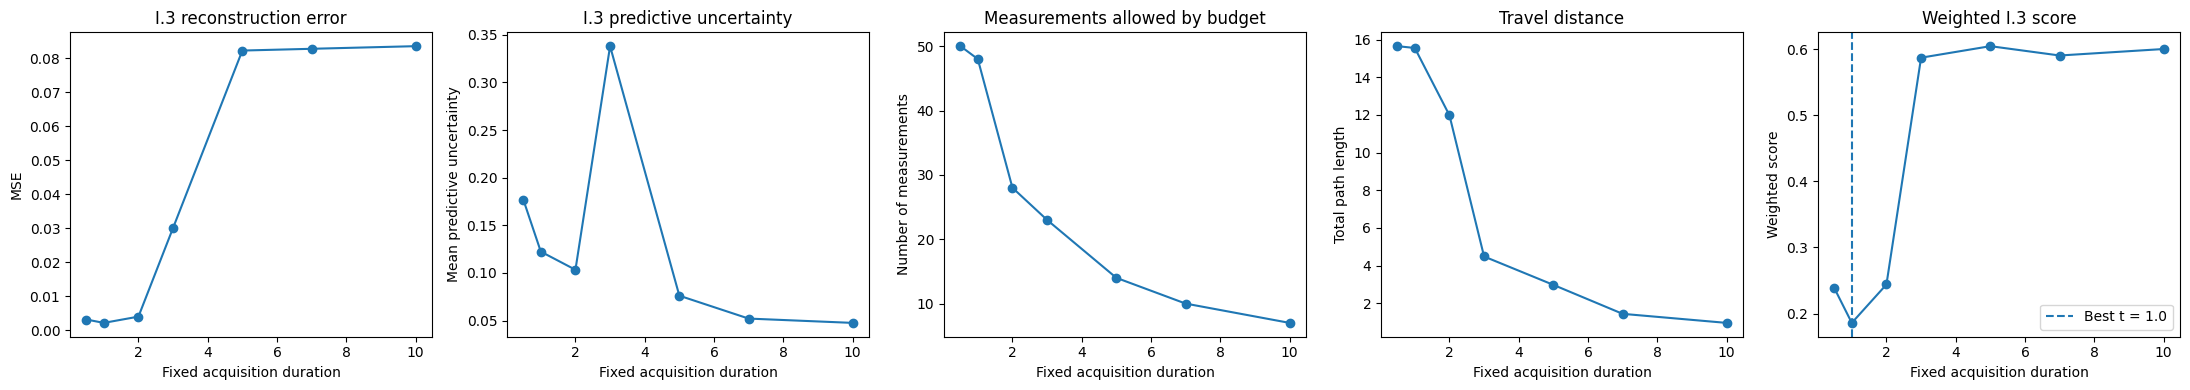

In [75]:
fig, ax = plt.subplots(1, 5, figsize=(22, 4))

ax[0].plot(i3_results_df["t_fixed"], i3_results_df["MSE"], "o-")
ax[0].set_xlabel("Fixed acquisition duration")
ax[0].set_ylabel("MSE")
ax[0].set_title("I.3 reconstruction error")

ax[1].plot(i3_results_df["t_fixed"], i3_results_df["mean_uncertainty"], "o-")
ax[1].set_xlabel("Fixed acquisition duration")
ax[1].set_ylabel("Mean predictive uncertainty")
ax[1].set_title("I.3 predictive uncertainty")

ax[2].plot(i3_results_df["t_fixed"], i3_results_df["N_points"], "o-")
ax[2].set_xlabel("Fixed acquisition duration")
ax[2].set_ylabel("Number of measurements")
ax[2].set_title("Measurements allowed by budget")

ax[3].plot(i3_results_df["t_fixed"], i3_results_df["total_path_length"], "o-")
ax[3].set_xlabel("Fixed acquisition duration")
ax[3].set_ylabel("Total path length")
ax[3].set_title("Travel distance")

ax[4].plot(i3_results_df["t_fixed"], i3_results_df["weighted_score"], "o-")
ax[4].axvline(
    best_i3_row["t_fixed"],
    linestyle="--",
    label=f"Best t = {best_i3_row['t_fixed']}"
)
ax[4].set_xlabel("Fixed acquisition duration")
ax[4].set_ylabel("Weighted score")
ax[4].set_title("Weighted I.3 score")
ax[4].legend()

plt.tight_layout()
plt.show()

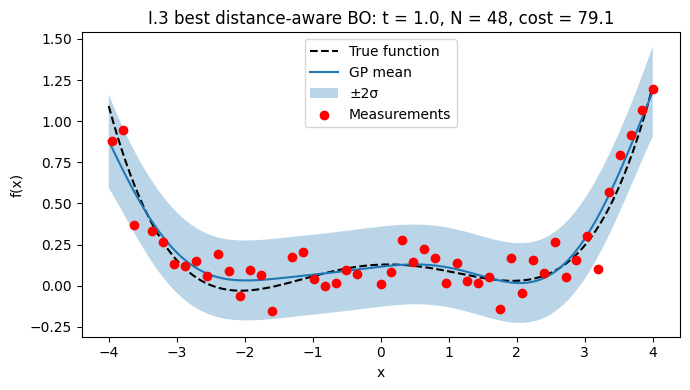

In [76]:
# -----------------------------
# Plot best I.3 BO reconstruction
# -----------------------------

best_t_i3 = best_i3_row["t_fixed"]
best_i3_result = i3_histories[best_t_i3]

x_train = best_i3_result["x_train"]
y_train = best_i3_result["y_train"]
mean = best_i3_result["mean"]
std = best_i3_result["std"]

plt.figure(figsize=(7, 4))

plt.plot(x_grid, y_true, "k--", label="True function")
plt.plot(x_grid, mean, label="GP mean")

plt.fill_between(
    x_grid,
    mean - 2 * std,
    mean + 2 * std,
    alpha=0.3,
    label="±2σ"
)

plt.scatter(
    x_train,
    y_train,
    color="red",
    zorder=3,
    label="Measurements"
)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title(
    f"I.3 best distance-aware BO: t = {best_t_i3}, "
    f"N = {len(x_train)}, cost = {best_i3_result['total_cost']:.1f}"
)
plt.legend()
plt.tight_layout()
plt.show()

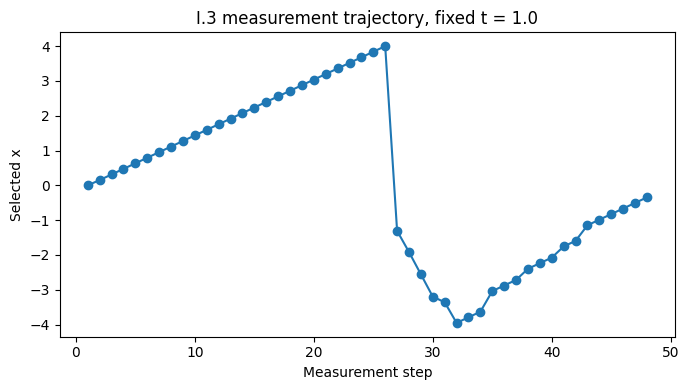

,step,x,t,travel_cost,measurement_cost,action_cost,total_cost,current_x_after,type
0,1,0.000000,1,0.000000,1,1.000000,1.000000,0.000000,initial
1,2,0.152305,1,0.304609,1,1.304609,2.304609,0.152305,BO
2,3,0.312625,1,0.320641,1,1.320641,3.625251,0.312625,BO
3,4,0.472946,1,0.320641,1,1.320641,4.945892,0.472946,BO
4,5,0.633267,1,0.320641,1,1.320641,6.266533,0.633267,BO
5,6,0.793587,1,0.320641,1,1.320641,7.587174,0.793587,BO
6,7,0.953908,1,0.320641,1,1.320641,8.907816,0.953908,BO
7,8,1.114228,1,0.320641,1,1.320641,10.228457,1.114228,BO
8,9,1.274549,1,0.320641,1,1.320641,11.549098,1.274549,BO
9,10,1.434870,1,0.320641,1,1.320641,12.869739,1.434870,BO


In [77]:
# -----------------------------
# Plot measurement order / trajectory
# -----------------------------

history = best_i3_result["history"]

plt.figure(figsize=(7, 4))

plt.plot(history["step"], history["x"], "o-")

plt.xlabel("Measurement step")
plt.ylabel("Selected x")
plt.title(f"I.3 measurement trajectory, fixed t = {best_t_i3}")
plt.tight_layout()
plt.show()

history

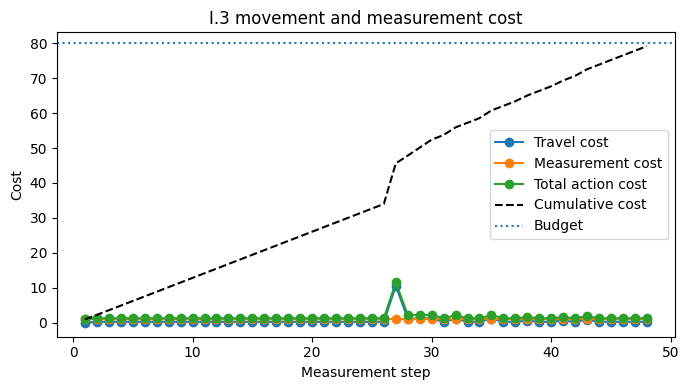

In [78]:
# -----------------------------
# Plot cost breakdown
# -----------------------------

history = best_i3_result["history"]

plt.figure(figsize=(7, 4))

plt.plot(history["step"], history["travel_cost"], "o-", label="Travel cost")
plt.plot(history["step"], history["measurement_cost"], "o-", label="Measurement cost")
plt.plot(history["step"], history["action_cost"], "o-", label="Total action cost")
plt.plot(history["step"], history["total_cost"], "k--", label="Cumulative cost")

plt.axhline(B, linestyle=":", label="Budget")

plt.xlabel("Measurement step")
plt.ylabel("Cost")
plt.title("I.3 movement and measurement cost")
plt.legend()
plt.tight_layout()
plt.show()

### Part II

Design a strategy that selects where to measure, in what order, and for how long, using the provided simulator and a fixed total budget. The objective is to reconstruct or optimize an unknown function as efficiently as possible under noisy measurements and movement cost. Implement and compare two different approaches for solving open decision making problem. You can choose from:

1. Dynamic Programming: plan actions by optimizing expected future rewards and costs over a finite horizon

2. Reinforcement Learning: learn a policy through interaction with the simulator

3. Value Function (surrogate/BO): select actions based on immediate utility (e.g., uncertainty or acquisition function)

4. Lookahed policy

5. ... and so on

Hint: brainstorm the overall problem with ChatGPT, and explore different possible startegies. Please pay specific attention to what is used to make decisions, and what should be experimental budget (i.e. how does the algorithm learn).

Each method must decide where to measure and how long (cost–noise trade-off). Plot exploration trajectory, cost for measurement/moving along the experimental cmapaign, and monitoring functions (e.g. value function for (x,t)). Evaluate performance in terms of reconstruction accuracy and budget efficiency. What advantage do we get compared to grid and myopic policies?







Method A

Explanation:

In [ ]:
#realization

In [ ]:
#metrics

Method B

Explanation

In [ ]:
#realization

In [ ]:
#metrics

Do you expect your algorithm to be transferable to a different scenario (e.g. function with maximum in different location) and what wuld it require?

Explanation